# Clasificador de Vinos con KNN

## 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

URL = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(URL, sep=";")

print("Shape:", df.shape)
df.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
# Exploración básica
print(df.info())
print("\nEstadísticas:")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Estadísticas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [3]:
# Distribución de la columna quality original
print("Distribución de quality:")
print(df["quality"].value_counts().sort_index())

# Crear columna label: 0=baja, 1=media, 2=alta
def quality_to_label(q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2

df["label"] = df["quality"].apply(quality_to_label)
print("\nDistribución de label:")
print(df["label"].value_counts().sort_index())

Distribución de quality:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Distribución de label:
label
0      63
1    1319
2     217
Name: count, dtype: int64


## 2. Entrenamiento del modelo KNN

In [4]:
# Separar variables independientes (X) del objetivo (y)
X = df.drop(columns=["quality", "label"])
y = df["label"]

# Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entrenamiento: {X_train_scaled.shape[0]} muestras")
print(f"Prueba:        {X_test_scaled.shape[0]} muestras")

Entrenamiento: 1279 muestras
Prueba:        320 muestras


In [5]:
# Entrenar con k=7 como valor inicial
k_initial = 7
knn = KNeighborsClassifier(n_neighbors=k_initial)
knn.fit(X_train_scaled, y_train)
print(f"Modelo KNN entrenado con k={k_initial}")

Modelo KNN entrenado con k=7


## 3. Evaluación del rendimiento

In [6]:
y_pred = knn.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (k={k_initial}): {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Baja", "Media", "Alta"]))

Accuracy (k=7): 0.8438

Classification Report:
              precision    recall  f1-score   support

        Baja       0.00      0.00      0.00        13
       Media       0.87      0.95      0.91       264
        Alta       0.61      0.47      0.53        43

    accuracy                           0.84       320
   macro avg       0.49      0.47      0.48       320
weighted avg       0.80      0.84      0.82       320



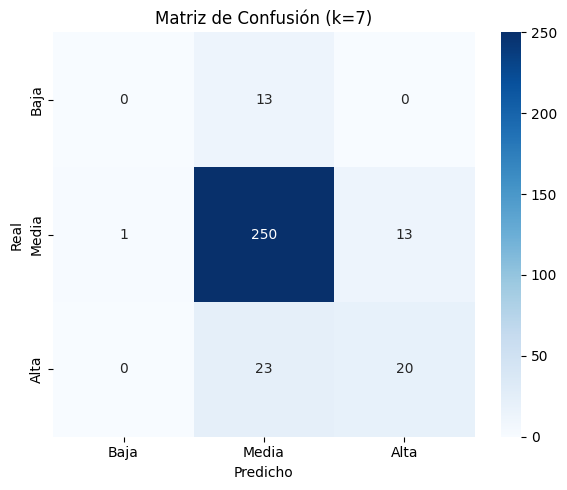

In [7]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Baja", "Media", "Alta"],
            yticklabels=["Baja", "Media", "Alta"])
plt.title(f"Matriz de Confusión (k={k_initial})")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

In [ ]:
# podemos observar que nuestro modelo no puede predecir si un vino es de calidad baja, y la predicción de si es de 
# calidad alta no es muy buena aceertando con aproximadamente el 50% mientras que la calidad media acerto 250 de 264 lo que lo hace un
#  excelente modelo ya que la mayoria de nuestros datos son de calidad media 

## 4. Optimización de k

In [8]:
# Probar k de 1 a 20 y guardar resultados
k_values = list(range(1, 21))
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, preds))

best_k = k_values[accuracies.index(max(accuracies))]
print(f"Mejor k: {best_k}  |  Accuracy: {max(accuracies):.4f}")

Mejor k: 11  |  Accuracy: 0.8594


In [ ]:
# con la optimización del modelo pudimos obtener incrementar un poco más del 1%

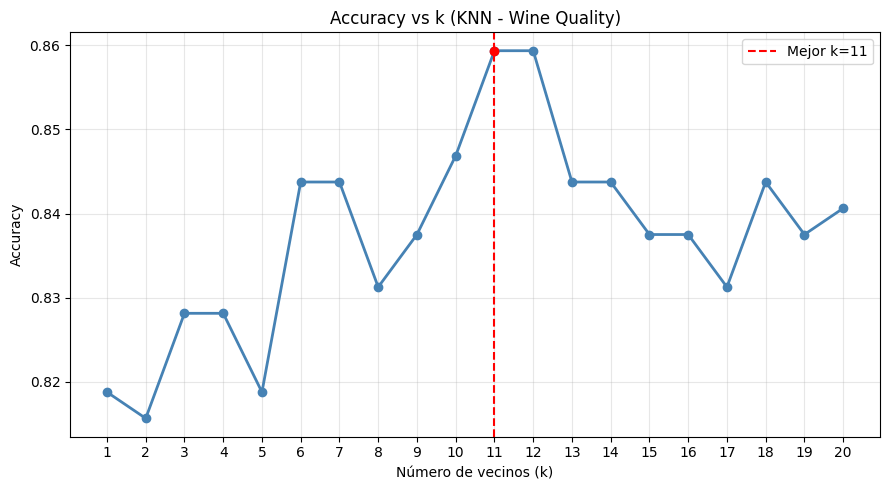

In [9]:
# Gráfica accuracy vs k
plt.figure(figsize=(9, 5))
plt.plot(k_values, accuracies, marker="o", color="steelblue", linewidth=2)
plt.axvline(best_k, color="red", linestyle="--", label=f"Mejor k={best_k}")
plt.scatter([best_k], [max(accuracies)], color="red", zorder=5)
plt.title("Accuracy vs k (KNN - Wine Quality)")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# aquí podemos observar graficamente la diferencia entre k=7 y k=11